In [14]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import kstest

from si import load_models, load_working_model_artifacts, run_one

In [19]:
d = 10  # feature dimension
n_s = 250   # n_s
n_t = 50   # n_t
n_ref = 200  # n_ref
top_k = 0.05 # top 5% as anomalies
alpha = 0.05
iters = 500  

# rho = 0.0, use correlated for rho = 0.5
model_name = "deepsad_da_delta2_independent"

In [16]:
encoder, deepsad_c, device = load_models(device="cpu", model_dir="models", model_name=model_name,
    d=d, h_dims=[64, 32], rep_dim=8,
)
deepsad_c = np.asarray(deepsad_c, dtype=np.float64)

artifacts = load_working_model_artifacts(model_dir="models", model_name=model_name)

Sigma_s = artifacts["Sigma_source"]
Sigma_t = artifacts["Sigma_target"]

print("Network: ", type(encoder).__name__)
print("Sigma^s: ", Sigma_s.shape, "| Sigma^t:", Sigma_t.shape)

Network:  DADeepSADEncoder
Sigma^s:  (10, 10) | Sigma^t: (10, 10)


In [20]:
p_values = []

for iter in range(iters):
    out = run_one(seed = iter, d=d, target_mu=0.0, source_mu=1.0,
        target_rho = 0.0, source_rho = 0.0,
        source_test_size = n_s, target_test_size=n_t, reference_size=n_ref,
        top_k_percent=top_k, delta=0.0, anomaly_rate=0.0,
        test_index_class="normal", selection_event="j-in-o",
        deepsad_encoder=encoder, deepsad_c=deepsad_c, device="cpu",
        Sigma_source=Sigma_s, Sigma_target=Sigma_t,
    )
    p_values.extend(p for p in out if p is not None)   # run_one returns a list

p_values = np.asarray(p_values)

p-value for seed 0: 0.1797898612515225
p-value for seed 1: 0.33312496925839263
p-value for seed 2: 0.6884808940948995
p-value for seed 3: 0.381395623456682
p-value for seed 4: 0.6222714750691146
p-value for seed 5: 0.038902017430820335
p-value for seed 6: 0.3369471036133984
p-value for seed 7: 0.4946497286401106
p-value for seed 8: 0.30073116010987166
p-value for seed 9: 0.8519645245871228
p-value for seed 10: 0.6235531543410945
p-value for seed 11: 0.39294055569797837
p-value for seed 12: 0.386736332000626
p-value for seed 13: 0.4866166449882037
p-value for seed 14: 0.7097831277824138
p-value for seed 15: 0.41096146711395964
p-value for seed 16: 0.12686095576457548
p-value for seed 17: 0.6095396993193338
p-value for seed 18: 0.9230543568885553
p-value for seed 19: 0.7565185877927756
p-value for seed 20: 0.2697945575076086
p-value for seed 21: 0.46381909756000983
p-value for seed 22: 0.638160739549927
p-value for seed 23: 0.5707843996938802
p-value for seed 24: 0.8987892912377456
p-val

FPR = 0.048484848484848485
KS-Test p-value: 0.2072260046169757


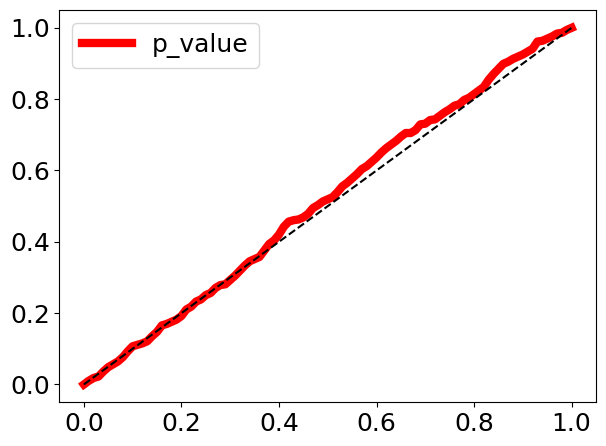

In [21]:
FPR = float(np.mean(p_values < alpha))
print(f"FPR = {FPR}")
stat, p_val = kstest(p_values, "uniform")
print(f"KS-Test p-value: {p_val}")

plt.rcParams.update({"font.size": 18})
grid = np.linspace(0, 1, 101)
ecdf = np.searchsorted(np.sort(p_values), grid, side="right") / len(p_values)

plt.plot(grid, ecdf, "r-", linewidth=6, label="p_value")
plt.plot([0, 1], [0, 1], "k--")
plt.legend()
plt.tight_layout()
plt.show()